# Exploratory Data Analysis (EDA) for the `flight_data_2024` dataset

## Engine Setup and Initialization

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Basic imports completed!")

import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, countDistinct
print("PySpark import completed!")

Basic imports completed!
PySpark import completed!


In [2]:
# aesthetic configuration of the graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
print("Spark Session initialization...")

# uses "local[*]" to tell Spark to use all cores on my Mac
spark = SparkSession.builder \
    .appName("FlightData_Full_EDA") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("\nSpark ready!")

Spark Session initialization...

Spark ready!


## Dataset Loading and Inspection

In [5]:
# Calculation of the absolute path for the complete dataset files
absolute_path_full = os.path.abspath("../dataset/raw/flight_data_2024.csv")
absolute_path_sample = os.path.abspath("../dataset/raw/flight_data_2024_sample.csv")
absolute_path_dict = os.path.abspath("../dataset/raw/flight_data_2024_data_dictionary.csv")
# disables Hadoop/HDFS search and forces local reading
file_path_full = f"file://{absolute_path_full}"
file_path_sample = f"file://{absolute_path_sample}"
file_path_dict = f"file://{absolute_path_dict}"

print(f"Attempt to read from the guaranteed local paths:\n {file_path_full}\n {file_path_sample}\n {file_path_dict}\n")
print("Reading files in progress...")

# inferSchema=False avoids scanning data types line by line, speeding up loading
df_full = spark.read.csv(file_path_full, header=True, inferSchema=False)
df_sample = spark.read.csv(file_path_sample, header=True, inferSchema=False)
df_dict = spark.read.csv(file_path_dict, header=True, inferSchema=False)

print("\nThe files have been read successfully!")

Attempt to read from the guaranteed local paths:
 file:///Users/fnene/development/mybd/Flight-Delay_Project/dataset/raw/flight_data_2024.csv
 file:///Users/fnene/development/mybd/Flight-Delay_Project/dataset/raw/flight_data_2024_sample.csv
 file:///Users/fnene/development/mybd/Flight-Delay_Project/dataset/raw/flight_data_2024_data_dictionary.csv

Reading files in progress...



The files have been read successfully!


### Dimensional Analysis

In [6]:
print("\nCalculating the dimensions of the dataset...")
total_rows = df_full.count()
total_cols = len(df_full.columns)
print(f"Dataset Dimensions: {total_rows:,} rows x {total_cols} columns.")


Calculating the dimensions of the dataset...


Dataset Dimensions: 7,079,081 rows x 35 columns.


*Observation*: **7,079,081 rows and 35 columns** were **loaded and counted in 6,7 seconds**, this can be possible because Spark divided the work into 10 parallel "tasks" using all processor cores.

### Structural Analysis

In [7]:
print("Dataset Dictionary:")
df_schema = df_dict.select(
    df_dict["column"].alias("Column Name"),
    df_dict["dtype"].alias("Data Type")
)
df_schema.show(total_cols, truncate=False)

Dataset Dictionary:
+-------------------+--------------+
|Column Name        |Data Type     |
+-------------------+--------------+
|year               |Int64         |
|month              |Int64         |
|day_of_month       |Int64         |
|day_of_week        |Int64         |
|fl_date            |datetime64[ns]|
|op_unique_carrier  |object        |
|op_carrier_fl_num  |float64       |
|origin             |object        |
|origin_city_name   |object        |
|origin_state_nm    |object        |
|dest               |object        |
|dest_city_name     |object        |
|dest_state_nm      |object        |
|crs_dep_time       |Int64         |
|dep_time           |float64       |
|dep_delay          |float64       |
|taxi_out           |float64       |
|wheels_off         |float64       |
|wheels_on          |float64       |
|taxi_in            |float64       |
|crs_arr_time       |Int64         |
|arr_time           |float64       |
|arr_delay          |float64       |
|cancelled        

*Observations*:
1. **Flight Identifiers**
    * `op_unique_carrier`: unique alphanumeric code that identifies the operating airline
    * `op_carrier_fl_num`: flight number
    * `origin`: IATA airport code (3 letters) of the departure airport
    * `dest`: IATA airport code of the destination airport
    * `distance`: physical distance between the origin and destination airports (expressed in miles)
2. **Temporal Variables**
    * `fl_date`: the day of the year on which the flight is scheduled (expressed in minutes)
    * `taxi_out`, `taxi_in`: taxiing time on departure and arrival
3. **Performance Metrics**
    * `crs_dep_time`, `crs_arr_time`: scheduled departure and arrival times
    * `dep_time`, `arr_time`: actual time the plane leaves the departure gate and arrives and stops at the destination gate
    * `dep_delay`, `arr_delay`: minutes of delay on departure and arrival
4. **Elapsed Time**
    * `crs_elapsed_time`: total travel minutes estimated by the company
    * `actual_elapsed_time`: total actual travel minutes
    * `air_time`: actual minutes spent in the air
5. **Cancellations or Exceptions**
    * `cancelled`: binary flag to indicate whether the flight has been cancelled or not
    * `cancellation_code`: reason for cancellation
    * `diverted`: binary flag to indicate whether the flight has been diverted to an airport other than the one originally scheduled
6. **Causes of Delay**
    * `carrier_delay`: minutes lost due to direct causes of the airline
    * `weather_delay`: minutes lost due to extreme weather conditions preventing safe operations
    * `nas_delay`: minutes lost due to causes attributable to the airport system or air traffic control
    * `security_delay`: minutes lost due to violations or delays at security checkpoints
    * `late_aircraft_delay`: minutes lost due to delays accumulated by the aircraft in previous flights

In [8]:
print("Data preview (first 5 rows):")
preview_data = df_full.limit(5).collect()
df_preview = pd.DataFrame([row.asDict() for row in preview_data])

display(df_preview)

Data preview (first 5 rows):


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


## Data Quality & Feature Selection

### Zero-Variance Analysis
To determine which attributes have zero variance, we opted for a **comparison between the min and max values**, rather than other solutions that would have required a (very heavy) shuffle operation.

All **columns with zero variance can be removed** from the dataset.

In [9]:
print("\nCalculating the columns with zero variance...")

# list to store columns with zero variance
zero_variance_cols = []

# create a list of instructions to calculate min and max for each column
exprs = [F.min(F.col(c)).alias(f"min_{c}") for c in df_full.columns] + [F.max(F.col(c)).alias(f"max_{c}") for c in df_full.columns]
# aggregation to get min and max values for all columns
min_max_row = df_full.select(*exprs).collect()[0].asDict()

print("Checking for min and max values for each column...")
# check if min and max are the same for each column
for c in df_full.columns:
    if min_max_row[f"min_{c}"] == min_max_row[f"max_{c}"]:
        zero_variance_cols.append(c)

print(f"\nZero-variance Columns: {zero_variance_cols}")


Calculating the columns with zero variance...


Checking for min and max values for each column...

Zero-variance Columns: ['year']


*Observation*: the only column with zero variance is the `year` attribute, which is expected since the dataset contains flight data for 2024.

### Redundancy Analysis
Analysis over the **sample to speed up** operations.

In [10]:
print("Calculating the redundancy of each column...")

# automatically identify columns that likely represent IDs (contain "_id" in their name)
id_cols = [c for c in df_sample.columns if "_id" in c.lower()]
redundant_cols = []

for c in id_cols:
    # base column identification
    base_col = c.lower().replace("_airport_id", "").replace("_id", "")
    
    if base_col in df_sample.columns:
        # approx_count_distinct function avoid the heavy shuffle
        # rsd parameter is set to 0.05 by default (the result will be within 5% of the true count)
        counts = df_sample.select(
            F.approx_count_distinct(c).alias("id_count"),
            F.approx_count_distinct(base_col).alias("base_count")
        ).collect()[0]

        count_id = counts["id_count"]
        count_base = counts["base_count"]

        # if counts are the same, we can consider the column redundant
        if abs(count_id - count_base) / count_id < 0.01: redundant_cols.append(c)

print(f"\nRedundant columns: {redundant_cols}")

Calculating the redundancy of each column...

Redundant columns: []


### Duplicate Analysis

In [11]:
print("Checking for exact duplicates...")
exact_duplicates = total_rows - df_full.dropDuplicates().count()
print(f"Exact duplicated records: {exact_duplicates}")

Checking for exact duplicates...


Exact duplicated records: 0


In [12]:
print("Checking for logical duplicates (same physical flight)...")
# two flight are logically duplicated if they have the same date, scheduled departure time, carrier, flight number, origin, destination
flight_keys = ["fl_date", "crs_dep_time", "op_unique_carrier", "op_carrier_fl_num", "origin", "dest",]
logical_duplicates = total_rows - df_full.dropDuplicates(flight_keys).count()
print(f"Logical duplicated records: {logical_duplicates}")

Checking for logical duplicates (same physical flight)...


Logical duplicated records: 0


### Sparsity Analysis

In [13]:
# expression to count the number of nulls in each column
col_null_exprs = [
    F.sum(F.when(F.col(c).isNull() | (F.col(c) == ""), 1).otherwise(0)).alias(c) 
    for c in df_full.columns
]

# expression to count the number of nulls in each row across all columns
row_null_expr = sum(
    F.when(F.col(c).isNull() | (F.col(c) == ""), 1).otherwise(0) 
    for c in df_full.columns
)
# expression to calculate the percentage of nulls per row
row_null_pct_expr = (row_null_expr / total_cols) * 100
# expression to count the number of records with more than 80% null values and not cancelled
sparse_records_expr = F.sum(
    F.when((row_null_pct_expr > 80) & (F.col("cancelled") == "0"), 1).otherwise(0)
).alias("total_sparse_records")

# combine all expressions into a single list for the final aggregation
all_exprs = col_null_exprs + [sparse_records_expr]

# aggregation to get the results for columns and records
all_results = df_full.select(*all_exprs).collect()[0].asDict()

print("Results ready!")

Results ready!


In [14]:
print("Searching for the columns with more than 80% missing values...")

# list to store columns with more than 80% null values
sparse_cols = []

print("\nColumns with more than 80% missing data:")
for c, null_count in all_results.items():
    null_pct = (null_count / total_rows) * 100
    
    if null_pct > 80:
        sparse_cols.append(c)
        print(f" > {c}: {null_pct:.1f}% missing")

print(f"\nSparse columns: {sparse_cols}")

Searching for the columns with more than 80% missing values...

Columns with more than 80% missing data:
 > cancellation_code: 98.6% missing

Sparse columns: ['cancellation_code']


*Observation*: **`cancellation_code`**, although sparse, is intentionally kept because **its null value carries information** (it indicates that the flight operated regularly)

In [15]:
print("Searching for the records with more than 80% missing values...")

# extract the count of sparse records from the results
sparse_records_count = all_results.pop("total_sparse_records")

print(f"\nTotal of sparse records: {sparse_records_count}")

Searching for the records with more than 80% missing values...

Total of sparse records: 0


### Null Value Analysis
It differs from sparsity analysis because in this step is **evaluated the quality of the data contained in the target attributes**.

In [16]:
# Columns of interest
analysis_columns = ["dep_delay", "arr_delay", "cancelled", "cancellation_code"]

print("Extraction of the number of null values ​​on target columns...")
target_nulls = {c: all_results[c] for c in analysis_columns}

df_nulls = pd.DataFrame(list(target_nulls.items()), columns=["Column", "Null Values"]).set_index("Column")
df_nulls["% of Total"] = (df_nulls["Null Values"] / total_rows) * 100

print("\nReport Null Values:")
display(df_nulls)

Extraction of the number of null values ​​on target columns...

Report Null Values:


,Null Values,% of Total
Column,,
dep_delay,92970,1.313306
arr_delay,113814,1.607751
cancelled,0,0.000000
cancellation_code,6982766,98.639442


*Observations*:
* `cancelled` (**0%** null) $\to$ we know with mathematical certainty whether all 7 million flights took off or not. There are **no gray areas**.
* `cancellation_code` (**98.6%** null) $\to$ almost 99% of flights took off and arrived regularly.
* `dep_delay` and `arr_delay` (~**1.3%** - **1.6%** null) $\to$ that ~1.4% of flights that have a cancellation code (i.e. cancelled flights) corresponds almost perfectly to the percentage of flights that lack a delay in departure or arrival. If they did not depart, they could not register a delay.

Cross-analysis of null values ​​demonstrates the **internal consistency of the dataset**.

## Univariate Analysis
The goal here is to **study the individual distribution of each feature**.

### Cancellation Analysis

In [17]:
print("Aggregating cancellation causes...")
cancellations = df_full.filter(F.col("cancelled") == "1") \
                       .groupBy("cancellation_code") \
                       .count() \
                       .orderBy("count", ascending=False)

# Creation of Pandas DataFrame for plotting
data_cancellations = cancellations.collect()
df_canc_pd = pd.DataFrame([row.asDict() for row in data_cancellations])
# remove rows where cancellation_code is null (if any)
df_canc_pd = df_canc_pd.dropna(subset=['cancellation_code']) 

Aggregating cancellation causes...


Drawing the plot...


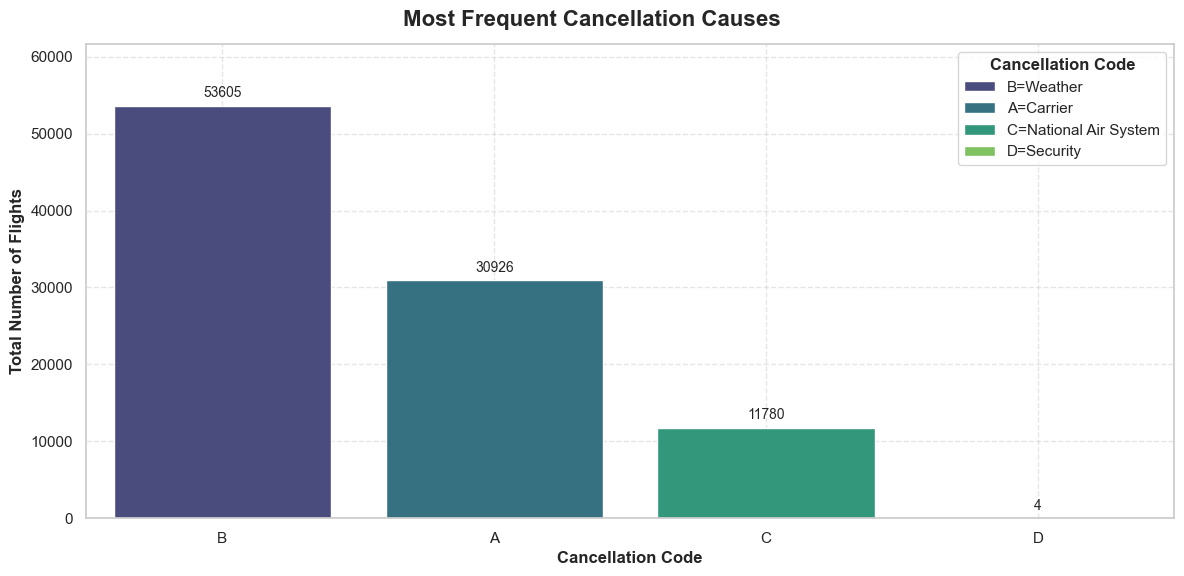

In [18]:
print("Drawing the plot...")
# Bar plot of cancellation causes
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_canc_pd, x='cancellation_code', y='count', 
                 palette='viridis', hue='cancellation_code')

plt.figtext(0.5, 0.93, 'Most Frequent Cancellation Causes', ha='center', fontweight='bold', fontsize=16)

code_mapping = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'National Air System',
    'D': 'Security'
}
handles, labels = ax.get_legend_handles_labels()
if not handles:
    handles = ax.patches[:len(df_canc_pd)]
    labels = [tick.get_text() for tick in ax.get_xticklabels()]

new_labels = [f"{label}={code_mapping.get(label, 'Unknown')}" for label in labels]

plt.legend(handles, new_labels, title='Cancellation Code', title_fontproperties={'weight': 'bold'})

plt.xlabel('Cancellation Code', fontweight='bold')
plt.ylabel('Total Number of Flights', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

max_height = df_canc_pd['count'].max()
ax.set_ylim(0, max_height * 1.15) 

for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0: 
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

*Observations*:
* Cause B (Weather), responsible for over 50,000 cancellations, is by far the leading cause.
* Code A (**Carrier**) is the second cause (about 30,000 flights), this is a **critical business fact** as it indicates that a huge portion of cancellations is attributable to internal operational problems within the companies.
* **Safety-related issues** (D) are **statistically insignificant** in terms of total volume compared to other causes.

### Causes of Delay Analysis

In [19]:
print("Aggregating delay causes...")

# sums all the minutes of delay for each cause and collects the result as a dictionary
delay_sums = df_full.select(
    F.sum("late_aircraft_delay").alias("Late Aircraft"),
    F.sum("carrier_delay").alias("Carrier"),
    F.sum("nas_delay").alias("National Air System (NAS)"),
    F.sum("weather_delay").alias("Weather"),
    F.sum("security_delay").alias("Security")
).collect()[0].asDict()

df_delay_pd = pd.DataFrame(list(delay_sums.items()), columns=['delay_cause', 'total_minutes'])

df_delay_pd = df_delay_pd.sort_values(by='total_minutes', ascending=False)
df_delay_pd['total_minutes'] = df_delay_pd['total_minutes'] / 1000000

Aggregating delay causes...


Drawing the plot...


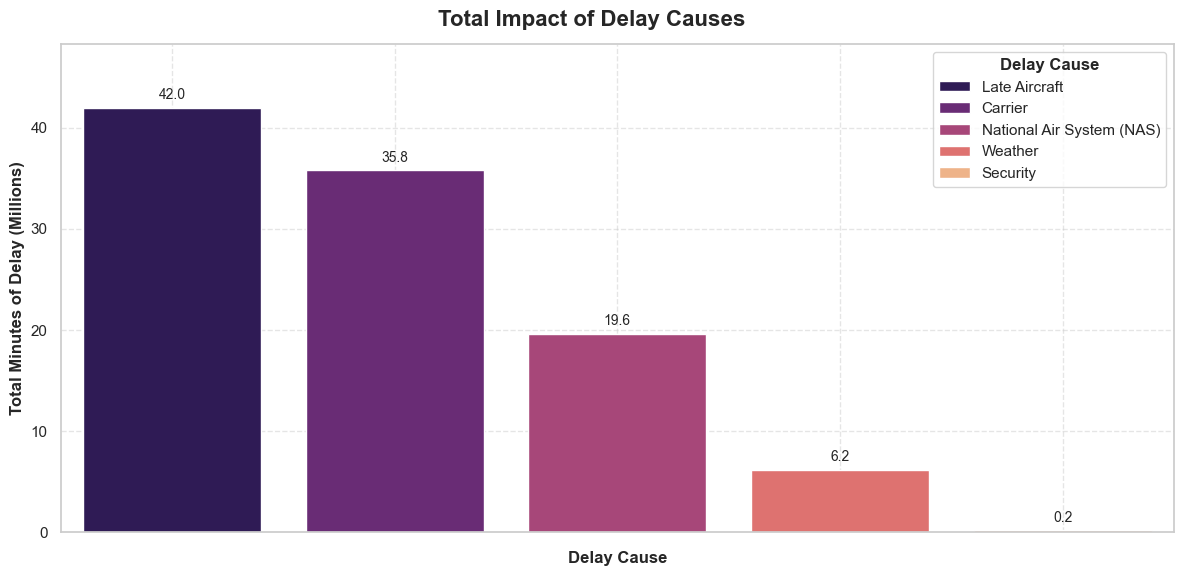

In [20]:
print("Drawing the plot...")
plt.figure(figsize=(12, 6))

# Bar plot of delay causes
ax = sns.barplot(data=df_delay_pd, x='delay_cause', y='total_minutes', 
                 palette='magma', hue='delay_cause')

plt.figtext(0.5, 0.93, 'Total Impact of Delay Causes', ha='center', fontweight='bold', fontsize=16)

plt.xlabel("Delay Cause", fontsize=12, fontweight='bold')
plt.ylabel("Total Minutes of Delay (Millions)", fontsize=12, fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
if not handles:
    handles = ax.patches[:len(df_delay_pd)]
    labels = [tick.get_text() for tick in ax.get_xticklabels()]

plt.legend(handles, labels, title='Delay Cause', title_fontproperties={'weight': 'bold'})

ax.set_xticklabels([])
ax.tick_params(axis='x', bottom=False)

plt.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

max_height = df_delay_pd['total_minutes'].max()
ax.set_ylim(0, max_height * 1.15) 

for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(f'{height:,.1f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

*Observations*:
* **Late Aircraft Delay** is the **main cause** of delays, this mathematically proves the existence of the Cascade Effect.
* In **second and third place** we find **delays attributable to the airline and the airport system**, this indicates that, net of unforeseen events, the aviation system suffers from chronic **infrastructural and logistical bottlenecks**.
* **Weather Delay** has a **significantly lower** cumulative **impact** than operational inefficiencies, this is because extreme adverse weather **tends to directly cause flight cancellations**.

### Distribution of Delays

In [21]:
print("Calculating delay brackets...")

# groups the delays in a histogram (excluding on-time/early flights and no-shows)
df_delays = df_full.filter(F.col("dep_delay").isNotNull()) \
                   .withColumn("dep_delay_num", F.col("dep_delay").cast("float"))

# extraction of delay bands
delay_bins = df_delays.withColumn("fascia", 
                    F.when(F.col("dep_delay_num") <= 0, "On Time / Early")
                   .when((F.col("dep_delay_num") > 0) & (F.col("dep_delay_num") <= 15), "Slight (<15m)")
                   .when((F.col("dep_delay_num") > 15) & (F.col("dep_delay_num") <= 60), "Medium (15-60m)")
                   .otherwise("Severe (>60m)")) \
                   .groupBy("fascia").count()

data_ranges = delay_bins.collect()
df_fasce_pd = pd.DataFrame([row.asDict() for row in data_ranges])

Calculating delay brackets...


Drawing the pie chart...


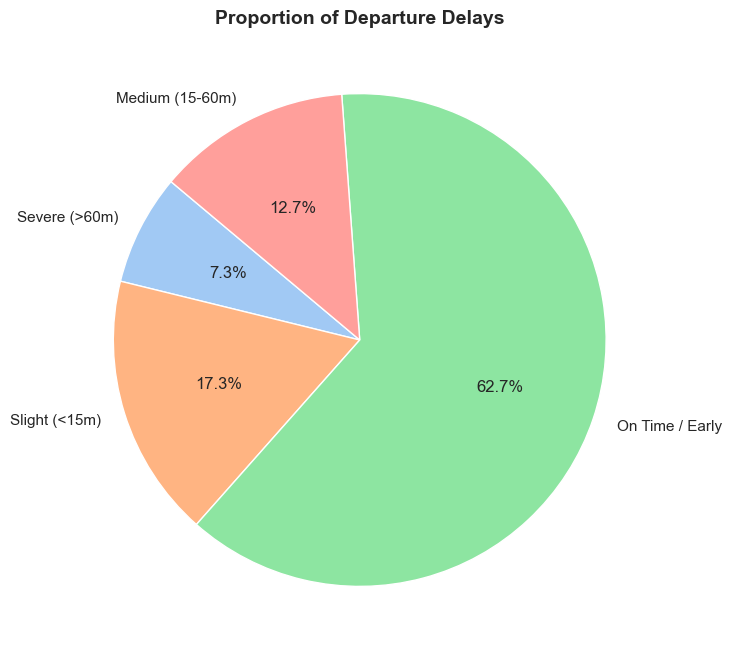

In [22]:
print("Drawing the pie chart...")
# Pie chart of delay proportions
plt.figure(figsize=(8, 8))
plt.pie(df_fasce_pd['count'], labels=df_fasce_pd['fascia'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proportion of Departure Delays", fontsize=14, fontweight='bold')
plt.show()

*Observation*: although almost two thirds of flights (**62.7%**) **depart on time** or even early, it is observed that, adding the "Medium" (12.7%) and "Severe" (7.3%) segments, **1 flight out of 5** (20%) **suffers a delay of more than 15 minutes**, creating potential inconvenience for passengers' connections.

### Outliers Identification
**Descriptive statistics** (mean, median, standard deviation, minimum, maximum, and quartiles) **allow to** immediately **identify** the presence of **extreme outliers and** to evaluate **skewness** and kurtosis.

In [23]:
print("Casting numeric columns and calculating summary...")

# numeric columns selection and casting to float
numeric_cols = ["arr_delay", "distance", "air_time", "actual_elapsed_time"]
for c in numeric_cols:
    df_full = df_full.withColumn(c, F.col(c).cast("float"))

stats_df = df_full.select(numeric_cols).summary("count", "min", "25%", "50%", "75%", "max", "mean")

stats_data = stats_df.collect()
df_stats_pd = pd.DataFrame([row.asDict() for row in stats_data]).set_index('summary')

# rounding to 2 decimal places for better readability
df_stats_pd = df_stats_pd.astype(float).round(2)

print("\nDescriptive Statistics:")
display(df_stats_pd)

Casting numeric columns and calculating summary...



Descriptive Statistics:


,arr_delay,distance,air_time,actual_elapsed_time
summary,,,,
count,6965267.0,7079081.00,6965267.0,6965267.00
min,-126.0,11.00,5.0,15.00
25%,-15.0,399.00,63.0,88.00
50%,-6.0,680.00,98.0,125.00
75%,9.0,1069.00,145.0,172.00
max,3803.0,5095.00,723.0,792.00
mean,7.1,833.91,115.0,141.22


*Observations*:
* The **median** (`50%`) is **-6.0**, meaning more than half of all American flights in 2024 arrived early; however, the **average** (`mean`) is positive (**7.1**). This phenomenon occurs due to **extreme outliers** — also observable by the `max` value of `arr_delay` = 3,803 minutes (at least one plane was delayed more than 63 hours) — extreme cases that **bias the mean upward**, creating a **right-skewed distribution**.
* The `count` value of `distance` = 7,079,081 rows (the exact total of rows in the dataset), while the other columns total is 6,965,267. The difference between these two numbers (approximately 113,814) corresponds exactly to the sum of canceled and diverted flights that never arrived at their destination, further confirming the dataset's consistency.
* As for extreme flights (`distance`), the **longest flight** (`max`) covers **5,095 miles** (probably a continental one); the truly curious anomaly is the **shortest flight** (`min`): **11 miles**, a "hop" between two very close airports (perhaps a flight to reposition the plane or to secondary stopovers on nearby islands).
* By comparing the averages of `act_elapsed_time` (time the plane's doors remain closed with passengers on board), approximately 141 minutes, and `air_time` (time the wheels are off the ground), 115 minutes, it is possible to determine the **average** physiological **time** that American flights waste **taxiing** on the runways before departure and arrival = approximately **26 minutes**.

In [24]:
print("Creating the Enriched Sample for the chart...")

df_sample_plot = df_sample.select(
    F.col("dep_delay").cast("float"), 
    F.col("arr_delay").cast("float")
).dropna()

print("Extracting real global outliers from the full dataset...")
top_dep = df_full.select(F.col("dep_delay").cast("float"), F.col("arr_delay").cast("float")).dropna().orderBy(F.desc("dep_delay")).limit(50)
bot_dep = df_full.select(F.col("dep_delay").cast("float"), F.col("arr_delay").cast("float")).dropna().orderBy(F.asc("dep_delay")).limit(50)

top_arr = df_full.select(F.col("dep_delay").cast("float"), F.col("arr_delay").cast("float")).dropna().orderBy(F.desc("arr_delay")).limit(50)
bot_arr = df_full.select(F.col("dep_delay").cast("float"), F.col("arr_delay").cast("float")).dropna().orderBy(F.asc("arr_delay")).limit(50)

# union of the sample with the extreme outliers
plot_spark_df = df_sample_plot.union(top_dep).union(bot_dep).union(top_arr).union(bot_arr).distinct()

collected_data = plot_spark_df.collect()
df_sample_plot = pd.DataFrame([row.asDict() for row in collected_data])

print("Enriched Sample ready!")

Creating the Enriched Sample for the chart...
Extracting real global outliers from the full dataset...


Enriched Sample ready!


Drawing the plots...


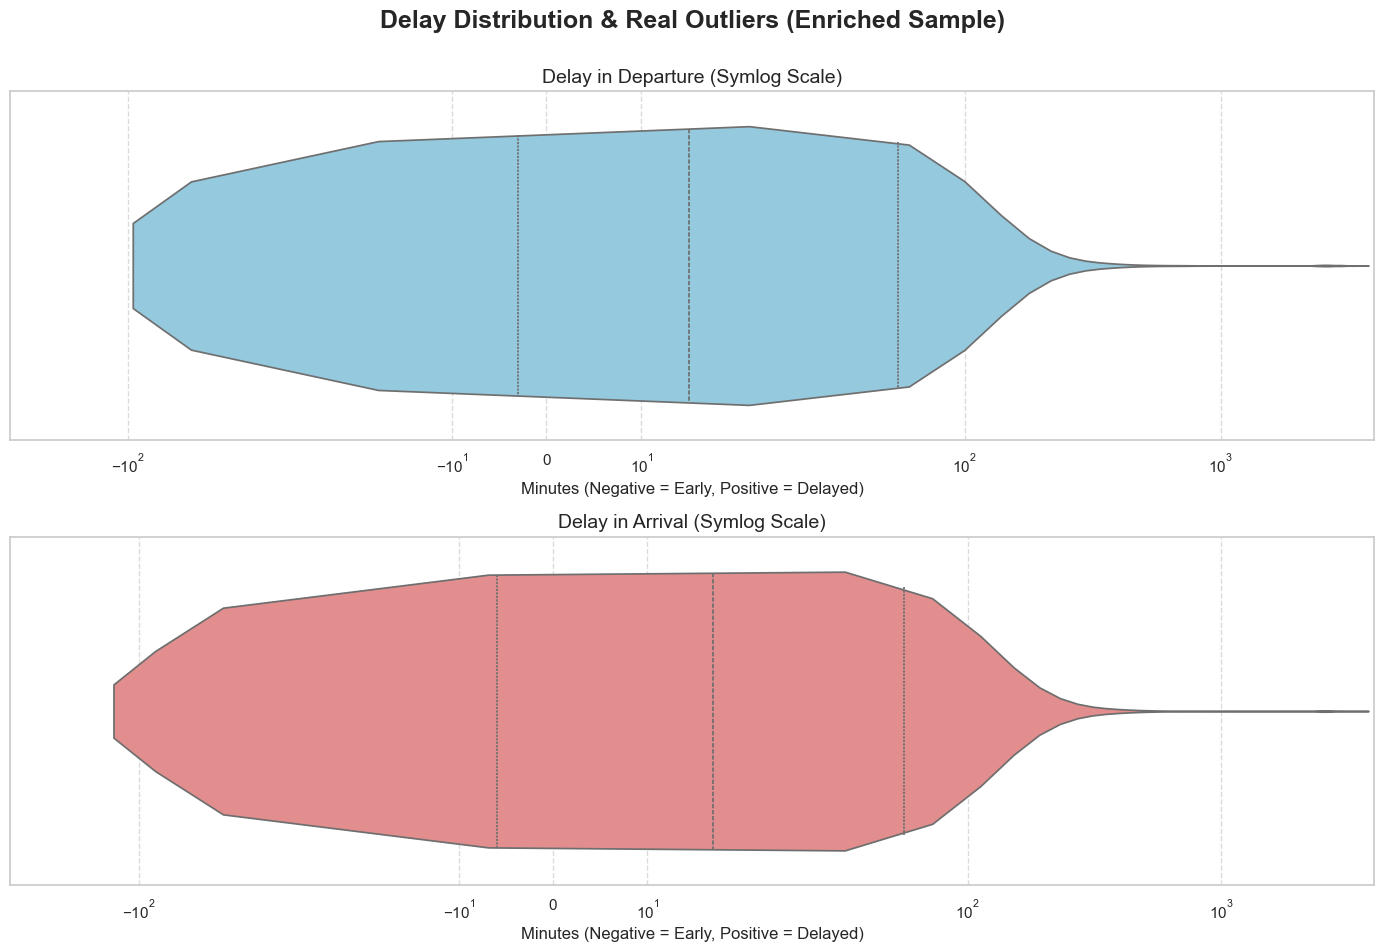

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10)) 
fig.suptitle('Delay Distribution & Real Outliers (Enriched Sample)', fontsize=18, fontweight='bold', y=0.95)

# --- Subplot 1 - Delay in Departure ---
sns.violinplot(x='dep_delay', data=df_sample_plot, ax=axes[0], color='skyblue', inner='quartile', cut=0)
axes[0].set_title('Delay in Departure (Symlog Scale)', fontsize=14)
axes[0].set_xlabel('Minutes (Negative = Early, Positive = Delayed)', fontsize=12)

# Symlog scale: linear between -30 and +30, logarithmic beyond that
axes[0].set_xscale('symlog', linthresh=30)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# --- Subplot 2 - Delay in Arrival ---
sns.violinplot(x='arr_delay', data=df_sample_plot, ax=axes[1], color='lightcoral', inner='quartile', cut=0)
axes[1].set_title('Delay in Arrival (Symlog Scale)', fontsize=14)
axes[1].set_xlabel('Minutes (Negative = Early, Positive = Delayed)', fontsize=12)

axes[1].set_xscale('symlog', linthresh=30)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

print("Drawing the plots...")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*Osservation*: **outliers**, while extreme and exceptional, are **real events** that should not be removed because they represent **significant anomalies that impact the performance** of an airline or airport.

## Bivariate Analysis
Try to find out **how the variables interact with each other** and, above all, with the target variables (`arr_delay`, `dep_delay`).

### Delays vs. Carrier Performance
This bivariate analysis aims to **highlight that punctuality is not uniformly distributed**: some airlines absorb a disproportionate share of total delays, suggesting that the `carrier` feature is a factor with high predictive power.

In [26]:
print("Aggregating average delays by carrier...")

# filters out nulls, calculates the average for each company, and sorts in descending order
carrier_delays = df_full.filter(F.col("dep_delay").isNotNull()) \
    .withColumn("dep_delay_num", F.col("dep_delay").cast("float")) \
    .groupBy("op_unique_carrier") \
    .agg(F.mean("dep_delay_num").alias("avg_dep_delay")) \
    .orderBy("avg_dep_delay", ascending=False)

carrier_pd = pd.DataFrame([row.asDict() for row in carrier_delays.collect()])

Aggregating average delays by carrier...


Drawing the plot...


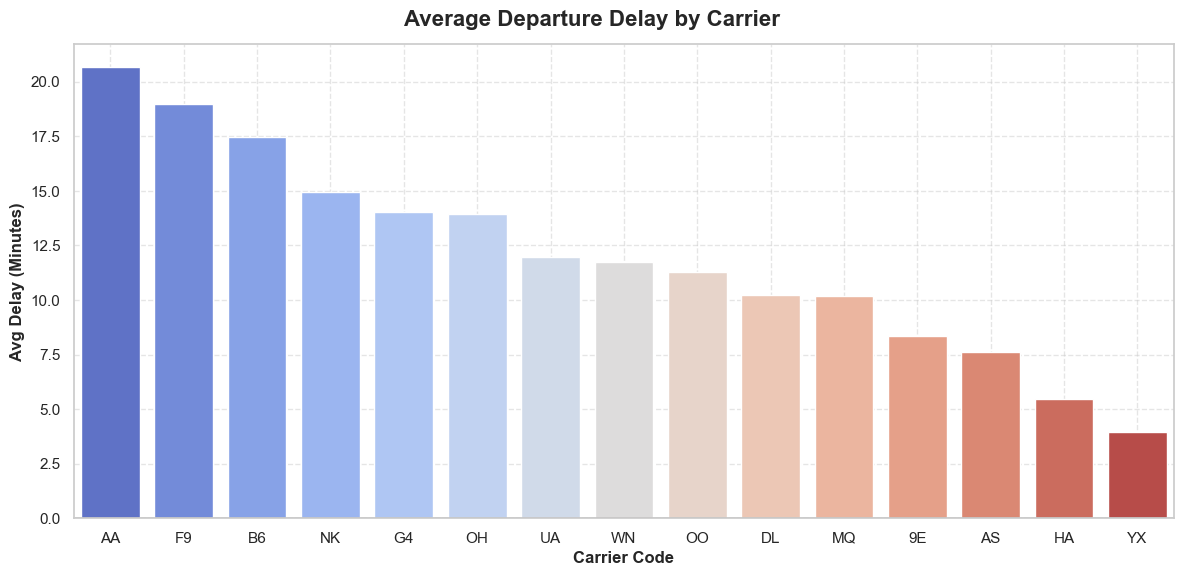

In [27]:
print("Drawing the plot...")
plt.figure(figsize=(12, 6))

# Barplot of average departure delay by carrier
ax = sns.barplot(data=carrier_pd, x='op_unique_carrier', y='avg_dep_delay', 
                 palette='coolwarm', hue='op_unique_carrier', legend=False)

plt.figtext(0.5, 0.93, 'Average Departure Delay by Carrier', ha='center', fontweight='bold', fontsize=16)

plt.xlabel("Carrier Code", fontsize=12, fontweight='bold')
plt.ylabel("Avg Delay (Minutes)", fontsize=12, fontweight='bold')

plt.axhline(0, color='black', linewidth=1)

plt.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Trend Analysis of Temporal Effect
The temporal analysis reveals the **impact of seasonality** and **demonstrates the cascade effect** of airport delays.

In [28]:
print("Aggregating average delays by month...")

# extract the average for each month
month_delays = df_full.filter(F.col("dep_delay").isNotNull()) \
    .withColumn("dep_delay_num", F.col("dep_delay").cast("float")) \
    .withColumn("month_num", F.col("month").cast("int")) \
    .groupBy("month_num") \
    .agg(F.mean("dep_delay_num").alias("avg_delay")) \
    .orderBy("month_num")

month_pd = pd.DataFrame([row.asDict() for row in month_delays.collect()])

# mapping of month numbers to names
mesi_nomi = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
month_pd['month_name'] = month_pd['month_num'].map(mesi_nomi)

Aggregating average delays by month...


Drawing the plot...


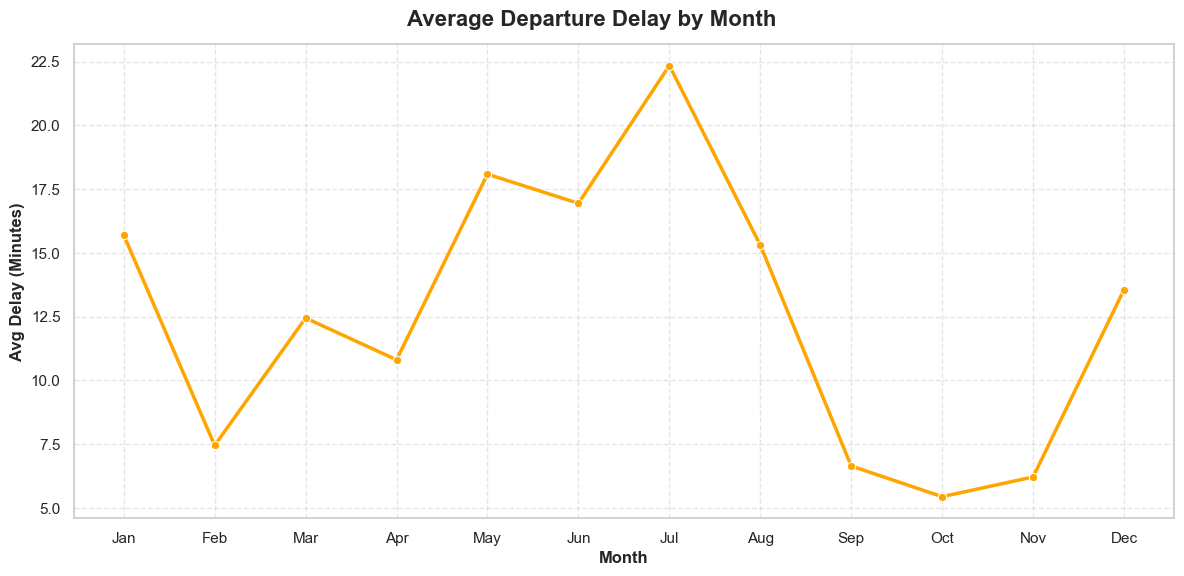

In [29]:
print("Drawing the plot...")
plt.figure(figsize=(12, 6))

ax = sns.lineplot(data=month_pd, x='month_name', y='avg_delay', 
                  marker='o', linewidth=2.5, color='orange')

plt.figtext(0.5, 0.93, 'Average Departure Delay by Month', ha='center', fontweight='bold', fontsize=16)

plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.ylabel("Avg Delay (Minutes)", fontsize=12, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

*Observations*:
* It is observed that air traffic suffers enormously during the summer (**absolute peak in July**).
* September, October, and November are the best times to travel, with delays dropping dramatically to an average of 5-7 minutes.

In [30]:
print("Aggregating average delay by hour of the day...")

# extract the hour from crs_dep_time (e.g., 1430 -> 14)
hourly_delays_spark = df_full.filter(F.col("cancelled") == "0") \
    .withColumn("hour", (F.col("crs_dep_time").cast("int") / 100).cast("int")) \
    .filter((F.col("hour") >= 0) & (F.col("hour") <= 23)) \
    .groupBy("hour") \
    .agg(F.mean(F.col("dep_delay").cast("float")).alias("avg_dep_delay")) \
    .orderBy("hour")

hourly_data = hourly_delays_spark.collect()
hourly_delays = pd.DataFrame([row.asDict() for row in hourly_data])

Aggregating average delay by hour of the day...


Drawing the line chart...


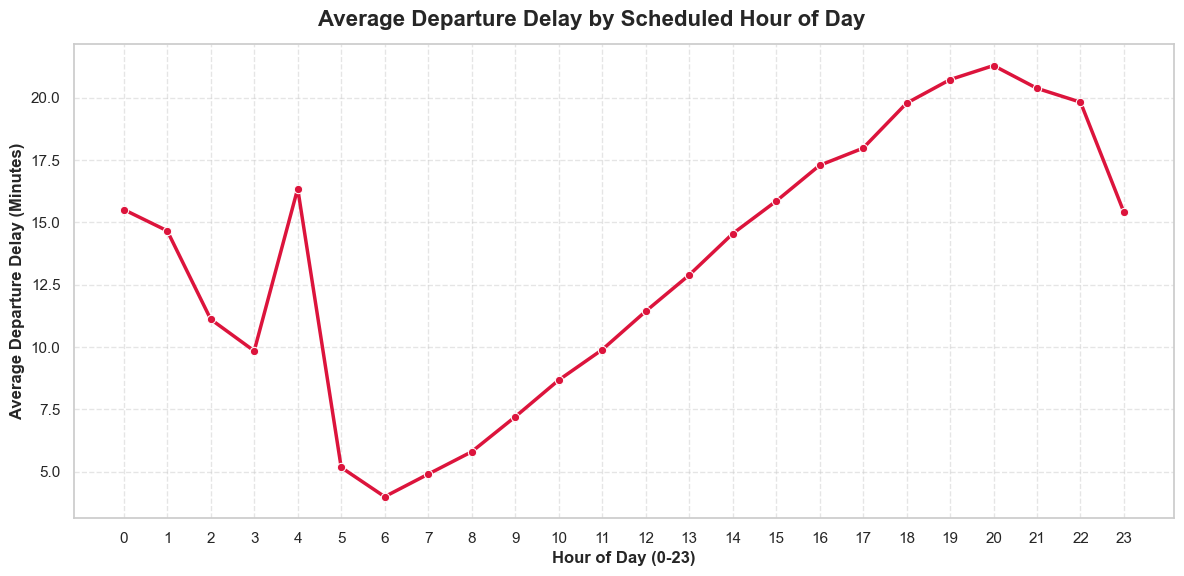

In [31]:
print("Drawing the line chart...")
plt.figure(figsize=(12, 6))

ax = sns.lineplot(data=hourly_delays, x='hour', y='avg_dep_delay', 
                  marker='o', linewidth=2.5, color='crimson')

plt.figtext(0.5, 0.93, 'Average Departure Delay by Scheduled Hour of Day', ha='center', fontweight='bold', fontsize=16)

plt.xlabel("Hour of Day (0-23)", fontsize=12, fontweight='bold')
plt.ylabel("Average Departure Delay (Minutes)", fontsize=12, fontweight='bold')

plt.xticks(range(0, 24))

plt.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

*Observations*:
* The curve hits its **absolute minimum** at **6am**, with an average delay of just 4 minutes. This could be because the planes have spent the night at the gate early in the morning, the crews are fresh, and there are no previous delays to clear. The **system is "reset"**.
* From 6:00 in the morning onwards, the **schedule increases almost linearly for 14 consecutive hours**. This happens because the same plane makes several trips during the day and even trivial delays accumulated in the morning are spread to subsequent flights, the infamous **"cascade effect"**.
* The **maximum peak** is recorded exactly at **8pm** (almost 22 minutes of average delay).
* There's a **sudden and very strange spike at 4am** (over 15 minutes). This is a classic **Big Data "statistical joke"**, a single plane delayed by 3 hours is enough to send the average skyrocketing.

### Recovery Analysis
A scatter plot over the sample dataset to show the **linear correlation between departure and arrival delays**.

*Note*: points below the diagonal represent flights that recovered time during cruise.

Calculating the correlation between departure and arrival delays...

Drawing the plot...


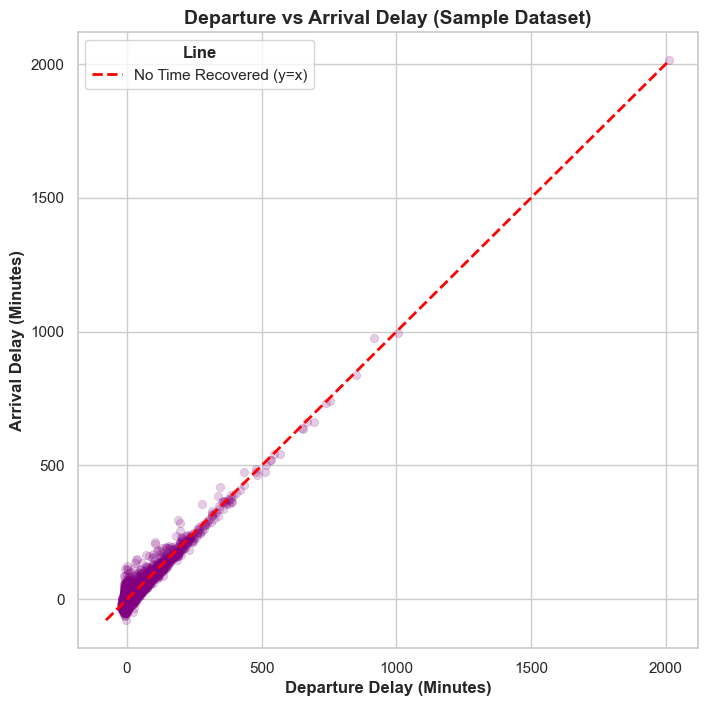

In [32]:
print("Calculating the correlation between departure and arrival delays...")

df_scatter = df_sample.filter(F.col("dep_delay").isNotNull() & F.col("arr_delay").isNotNull()) \
    .select(F.col("dep_delay").cast("float"), F.col("arr_delay").cast("float"))

scatter_pd = pd.DataFrame([row.asDict() for row in df_scatter.collect()])

print("\nDrawing the plot...")
# Scatterplot of departure delay vs arrival delay
plt.figure(figsize=(8, 8))
sns.scatterplot(data=scatter_pd, x='dep_delay', y='arr_delay', alpha=0.2, color='purple', edgecolor=None)
# add a reference line where arrival delay equals departure delay (y=x)
min_val = min(scatter_pd['dep_delay'].min(), scatter_pd['arr_delay'].min())
max_val = max(scatter_pd['dep_delay'].max(), scatter_pd['arr_delay'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="No Time Recovered (y=x)")
# drawing the plot
plt.title("Departure vs Arrival Delay (Sample Dataset)", fontsize=14, fontweight='bold')
plt.xlabel("Departure Delay (Minutes)", fontweight='bold')
plt.ylabel("Arrival Delay (Minutes)", fontweight='bold')
plt.legend(title='Line', title_fontproperties={'weight': 'bold'})
plt.show()

*Observations*:
* The **strongest linear correlation** is the expected one, that is, that a delay in departure almost always translates into the exact same delay in arrival ($y=x$).
* The most important observation in this case is the **dense cloud of purple points concentrated under the red line**, these represent **flights that departed late but managed to arrive with a delay less** than that accumulated at take-off (making up time in the air).